# Step 2: Audio-Text Similarity Analysis

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.dirname(os.getcwd())
RESULTS_DIR = os.path.join(PROJECT_DIR, 'outputs')
CSV_PATH    = os.path.join(PROJECT_DIR, 'data', 'metadata_500.csv')
AUDIO_DIR   = os.path.join(PROJECT_DIR, 'data', 'audio')

EMBED_DIR   = os.path.join(RESULTS_DIR, 'embeddings')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(EMBED_DIR,   exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# load embeddings
audio_emb = np.load(os.path.join(EMBED_DIR, 'audio_embeddings.npy'))  # (497, 512)
text_emb  = np.load(os.path.join(EMBED_DIR, 'text_embeddings.npy'))   # (497, 512)

# filter out bad files, consistent with notebook 01
import soundfile as sf
df = pd.read_csv(CSV_PATH)
audio_paths = [os.path.join(AUDIO_DIR, row['audio_filename']) for _, row in df.iterrows()]
bad_set = set()
for p in audio_paths:
    try:
        data, _ = sf.read(p)
        if len(data) == 0:
            bad_set.add(p)
    except:
        bad_set.add(p)
clean_df = df[[p not in bad_set for p in audio_paths]].reset_index(drop=True)

print('audio_emb shape:', audio_emb.shape)
print('text_emb shape: ', text_emb.shape)
print('num samples:', len(clean_df))

audio_emb shape: (497, 512)
text_emb shape:  (497, 512)
num samples: 497


In [3]:
# L2 normalize (cosine similarity = dot product of normalized vectors)
audio_norm = audio_emb / np.linalg.norm(audio_emb, axis=1, keepdims=True)
text_norm  = text_emb  / np.linalg.norm(text_emb,  axis=1, keepdims=True)

# 497x497 similarity matrix
sim_matrix = audio_norm @ text_norm.T  # (497, 497)

# diagonal = paired similarity
paired_sim = np.diag(sim_matrix)

print('similarity matrix shape:', sim_matrix.shape)
print(f'paired similarity  mean: {paired_sim.mean():.4f}')
print(f'paired similarity  max:  {paired_sim.max():.4f}')
print(f'paired similarity  min:  {paired_sim.min():.4f}')

similarity matrix shape: (497, 497)
paired similarity  mean: 0.3778
paired similarity  max:  0.7214
paired similarity  min:  -0.0639


In [4]:
# retrieval metrics: Audio -> Text (given audio, can we find the matching text)
def compute_retrieval_metrics(sim_matrix):
    n = sim_matrix.shape[0]
    # rank each row by similarity descending, check where correct match (diagonal) lands
    ranks = []
    for i in range(n):
        row = sim_matrix[i]
        rank = np.sum(row >= row[i]) - 1  # how many scores >= this (0-indexed rank)
        ranks.append(rank)
    ranks = np.array(ranks)
    metrics = {
        'R@1':  float(np.mean(ranks < 1)),
        'R@5':  float(np.mean(ranks < 5)),
        'R@10': float(np.mean(ranks < 10)),
        'MedR': float(np.median(ranks) + 1),
    }
    return metrics

a2t = compute_retrieval_metrics(sim_matrix)    # Audio -> Text
t2a = compute_retrieval_metrics(sim_matrix.T)  # Text -> Audio

print('Audio -> Text:')
for k, v in a2t.items():
    print(f'  {k}: {v:.4f}')
print('Text -> Audio:')
for k, v in t2a.items():
    print(f'  {k}: {v:.4f}')

Audio -> Text:
  R@1: 0.2636
  R@5: 0.6680
  R@10: 0.8028
  MedR: 3.0000
Text -> Audio:
  R@1: 0.2535
  R@5: 0.6901
  R@10: 0.8270
  MedR: 3.0000


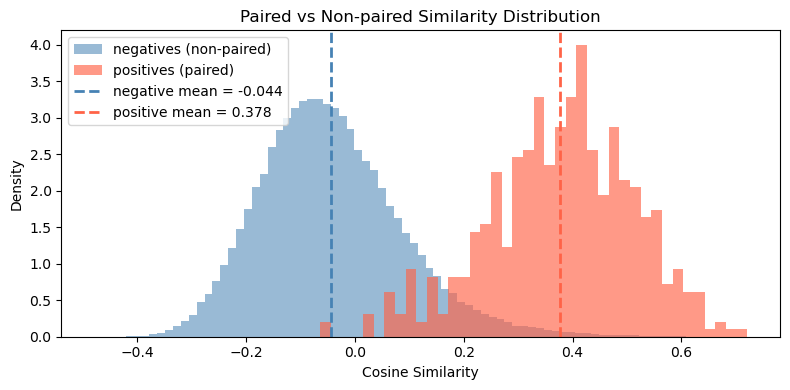

In [5]:
# visualization 1: paired similarity distribution (positives vs negatives)
off_diag = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)]

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    off_diag,
    bins=80,
    density=True,
    alpha=0.55,
    label='negatives (non-paired)',
    color='steelblue'
)

ax.hist(
    paired_sim,
    bins=40,
    density=True,
    alpha=0.65,
    label='positives (paired)',
    color='tomato'
)

ax.axvline(np.mean(off_diag), color='steelblue', linestyle='--', linewidth=2,
           label=f'negative mean = {np.mean(off_diag):.3f}')
ax.axvline(np.mean(paired_sim), color='tomato', linestyle='--', linewidth=2,
           label=f'positive mean = {np.mean(paired_sim):.3f}')

ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Paired vs Non-paired Similarity Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'similarity_distribution_density.png'), dpi=150)
plt.show()

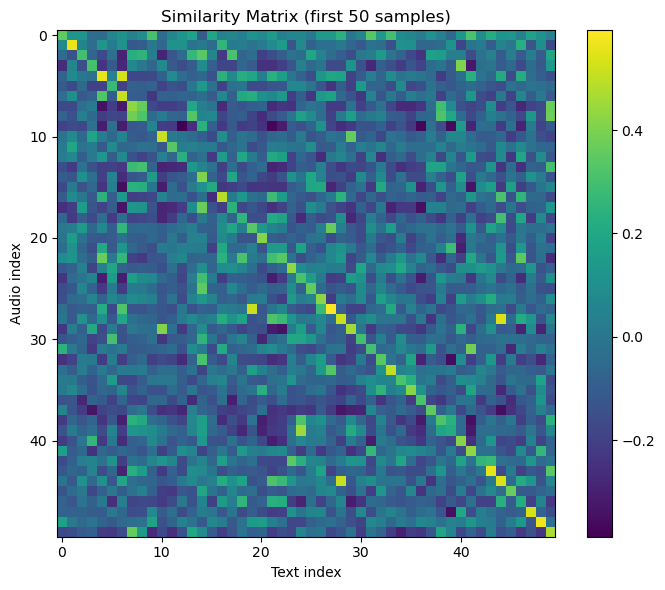

In [6]:
# visualization 2: similarity matrix heatmap (first 50 samples to check diagonal prominence)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix[:50, :50], cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('Similarity Matrix (first 50 samples)')
ax.set_xlabel('Text index')
ax.set_ylabel('Audio index')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'similarity_matrix.png'), dpi=150)
plt.show()

In [7]:
# find samples with highest and lowest paired similarity
top5_idx = np.argsort(paired_sim)[::-1][:5]
bot5_idx = np.argsort(paired_sim)[:5]

print('top 5 most similar pairs:')
for i in top5_idx:
    print(f'  [{i}] sim={paired_sim[i]:.4f} | {clean_df.iloc[i]["caption"]}')

print('\nbottom 5 least similar pairs:')
for i in bot5_idx:
    print(f'  [{i}] sim={paired_sim[i]:.4f} | {clean_df.iloc[i]["caption"]}')

top 5 most similar pairs:
  [392] sim=0.7214 | loud, continuous tapping on a typewriter
  [121] sim=0.6831 | two men speaking with loud insects buzzing
  [355] sim=0.6735 | Snoring and then a speech
  [373] sim=0.6684 | food and oil sizzling followed by oil popping then steam hissing as a man talks and light music plays in the background
  [249] sim=0.6489 | wind blowing heavily into a microphone as a speedboat drives by and water splashes in the distance followed by a man talking

bottom 5 least similar pairs:
  [187] sim=-0.0639 | music plays as a man is singing followed by muffled rapid gunshots firing
  [59] sim=-0.0516 | music is playing with machine gun sounds
  [421] sim=0.0154 | white noise continues then something begins clicking
  [61] sim=0.0290 | nature sounds with a frog croaking
  [439] sim=0.0303 | gravely sound with womans voice in background


In [8]:
# save similarity matrix and paired similarities
np.save(os.path.join(EMBED_DIR, 'sim_matrix.npy'),  sim_matrix)
np.save(os.path.join(EMBED_DIR, 'paired_sim.npy'),  paired_sim)
print('saved!')

saved!
